In [38]:
import time
import pandas as pd
import json
import numpy as np
from datetime import datetime
from datetime import timezone
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import random
import copy

SEARCH_BEST_ESN_MODEL = True

In [39]:
def remove_specific_cycles(data_loader, indices_to_remove):
    """
    Excludes specific indices from every key in the dataset.
    indices_to_remove: list of integers (e.g., [1, 3, 6])
    """
    cleaned_data = {}
    
    for key in data_loader.files:
        original_list = list(data_loader[key])
        # Keep only the items whose index is NOT in our 'remove' list
        cleaned_data[key] = [
            cycle for i, cycle in enumerate(original_list) 
            if i not in indices_to_remove
        ]
        
    return cleaned_data

def get_cycle_stats(data_source, param_prefix, leg, norm_points=100):
    """
    Interpolates cycles for a specific leg/parameter and calculates mean/std.
    """
    key = f'{param_prefix}_{leg}'
    if key not in data_source:
        return None, None, None

    raw_cycles = data_source[key]
    normalized_list = []
    

    for j, cycle in enumerate(raw_cycles):
            
        x_old = np.linspace(0, 100, len(cycle))
        x_new = np.linspace(0, 100, norm_points)
        norm_cycle = np.interp(x_new, x_old, cycle)
        normalized_list.append(norm_cycle)
    
    if not normalized_list:
        return None, None, None

    norm_matrix = np.array(normalized_list)
    mean_vals = np.mean(norm_matrix, axis=0)
    std_vals = np.std(norm_matrix, axis=0)
    x_axis = np.linspace(0, 100, norm_points)

    return x_axis, mean_vals, std_vals

In [40]:
def load_cycles_from_npz(filename):
    """
    Loads a flattened .npz file and reconstructs the nested dictionary.
    """
    data = np.load(filename)
    reconstructed = {}
    
    for key in data.files:
        # Split the key (e.g., 'rough_foot_force')
        # We use rsplit once from the right to handle sensor names with underscores
        parts = key.split('_', 2) 
        if len(parts) < 2: continue
        
        terrain, sensor = f"{parts[0]}_{parts[1]}", parts[2]
        
        if terrain not in reconstructed:
            reconstructed[terrain] = {}
        
        # Convert the (N, 100, F) array back into a list of (100, F) arrays
        # This makes it compatible with your existing segment_all_trials output
        reconstructed[terrain][sensor] = [cycle for cycle in data[key]]
        
    print(f"Loaded {len(reconstructed)} terrains from {filename}")
    return reconstructed

# --- Execution ---
dataset = load_cycles_from_npz('walking_terrain_datasets.npz')

Loaded 6 terrains from walking_terrain_datasets.npz


In [41]:
print(dataset.keys())
print(dataset['solid_ground'].keys())

dict_keys(['solid_ground', 'soft_ground', 'slippery_ground', 'rough_ground', 'muddy_ground', 'water_surface'])
dict_keys(['cpg_output', 'foot_force', 'leg_stiffness', 'leg_damping', 'leg_torque_feedforward', 'joint_commands', 'joint_angle_fb', 'joint_torque_fb', 'joint_stiffness_fb', 'joint_damping_fb', 'joint_torque_ff_fb'])


In [42]:
name_joints = ['FR_J1', 'FR_J2', 'FR_J3', 'FR_J4', 
 'BR_J1', 'BR_J2', 'BR_J3', 'BR_J4', 
 'FL_J1', 'FL_J2', 'FL_J3', 'FL_J4', 
 'BL_J1', 'BL_J2', 'BL_J3', 'BL_J4']

name_legs = ['FR', 'BR', 'FL', 'BL']

# Plot Dataset

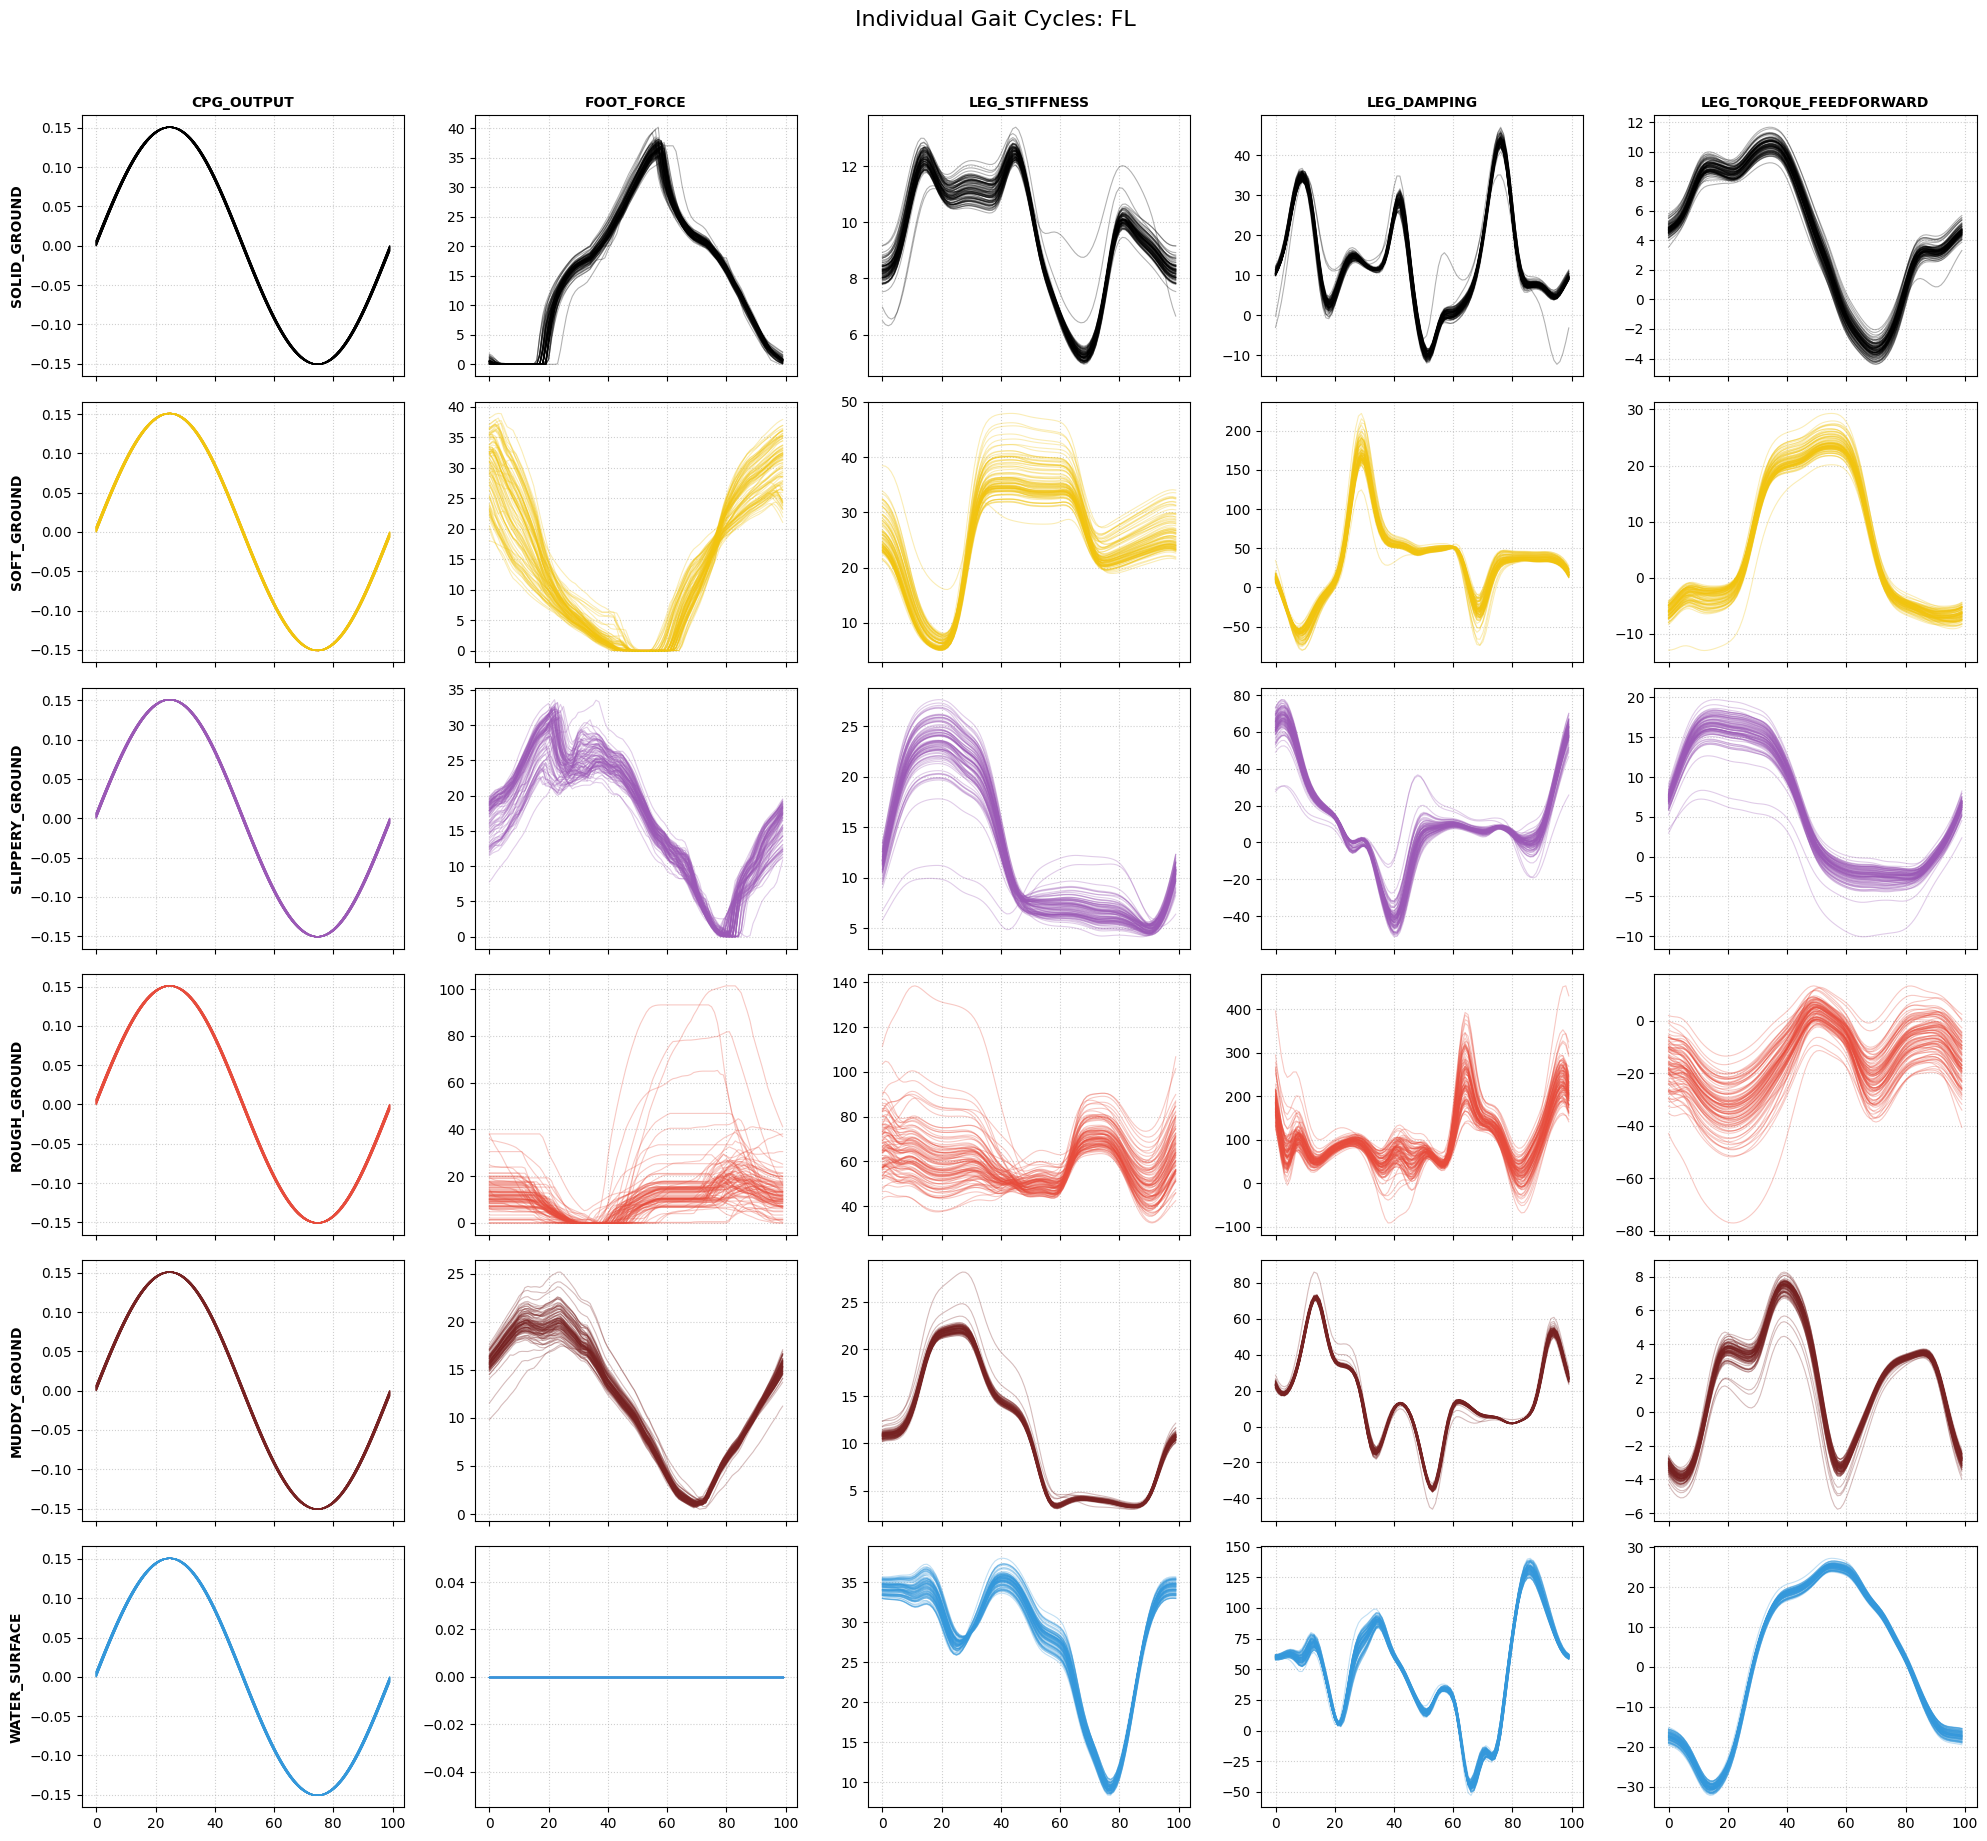

In [43]:
def plot_all_individual_cycles(cycle_results, sensor_list, leg_idx=0):
    """
    Plots every single cycle for every terrain to see the raw distribution.
    """
    terrains = list(cycle_results.keys())
    num_terrains = len(terrains)
    num_sensors = len(sensor_list)
    
    colors = {
        'solid_ground': "#000000", 'rough_ground': '#e74c3c', 'water_surface': '#3498db', 
        'soft_ground': '#f1c40f', 'muddy_ground': "#772222", 'slippery_ground': '#9b59b6'
    }

    # Use a dynamic title based on the index
    # We try to find the name from the global scope, otherwise use the index number
    try:
        # Check if the first sensor in the list is a leg or joint sensor
        is_joint = 'joint' in sensor_list[0]
        feature_name = name_joints[leg_idx] if is_joint else name_legs[leg_idx]
    except (NameError, IndexError):
        feature_name = f"Index {leg_idx}"

    fig, axes = plt.subplots(num_terrains, num_sensors, 
                               figsize=(4 * num_sensors, 3 * num_terrains), 
                               sharex=True, squeeze=False) # squeeze=False keeps axes 2D (rows, cols)

    for t_idx, terrain in enumerate(terrains):
        for s_idx, sensor in enumerate(sensor_list):
            ax = axes[t_idx, s_idx]
            
            # Use .get() to avoid KeyError if a sensor is missing for a terrain
            cycles = cycle_results.get(terrain, {}).get(sensor, [])
            
            if not cycles or len(cycles) == 0:
                ax.text(0.5, 0.5, 'No Data', ha='center', transform=ax.transAxes)
                continue
            
            color = colors.get(terrain, 'black')
            
            # Plot every single cycle
            for cycle in cycles:
                # cycle shape is (100, num_features)
                ax.plot(cycle[:, leg_idx], color=color, alpha=0.3, linewidth=0.8)
            
            # Formatting titles only for the top row
            if t_idx == 0:
                ax.set_title(f"{sensor.upper()}", fontsize=10, fontweight='bold')
            
            # Formatting labels only for the first column
            if s_idx == 0:
                ax.set_ylabel(f"{terrain.upper()}", fontsize=10, fontweight='bold')
            
            ax.grid(True, linestyle=':', alpha=0.6)

    plt.suptitle(f"Individual Gait Cycles: {feature_name}", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# --- Execution ---
sensors_to_plot = ['cpg_output', 'foot_force', 'leg_stiffness', 'leg_damping', 'leg_torque_feedforward']
plot_all_individual_cycles(dataset, sensors_to_plot, leg_idx=2)

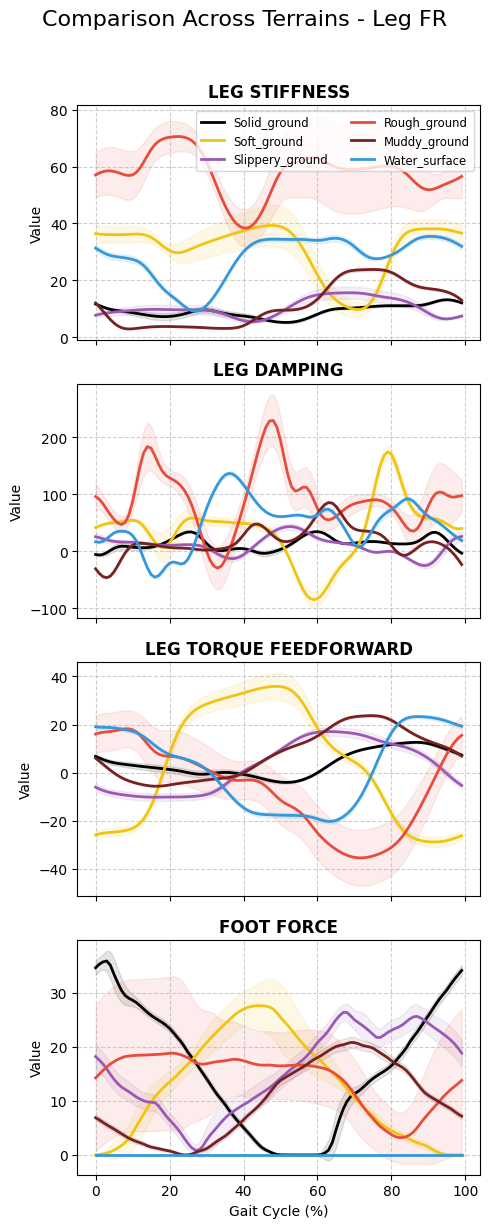

In [44]:

def plot_all_sensors_comparison(cycle_results, sensor_list, feature_index=0, feature_name="Leg 0"):
    """
    Creates a vertical stack of subplots comparing multiple sensors across all terrains.
    """
    terrains = list(cycle_results.keys())
    colors = {
        'solid_ground': "#000000", 'rough_ground': '#e74c3c', 'water_surface': '#3498db', 
        'soft_ground': '#f1c40f', 'muddy_ground': "#772222", 'slippery_ground': '#9b59b6'
    }
    num_sensors = len(sensor_list)
    fig, axes = plt.subplots(num_sensors, 1, figsize=(5, 3 * num_sensors), sharex=True)
    
    # Ensure axes is iterable even if there's only one sensor
    if num_sensors == 1:
        axes = [axes]

    for i, sensor_name in enumerate(sensor_list):
        ax = axes[i]
        
        for terrain in terrains:
            # Check if data exists for this terrain/sensor combo
            cycles = cycle_results.get(terrain, {}).get(sensor_name, [])
            if not cycles:
                continue
                
            data_stack = np.stack(cycles)
            feature_data = data_stack[:, :, feature_index]
            
            mean_traj = np.mean(feature_data, axis=0)
            std_traj = np.std(feature_data, axis=0)
            
            x = np.arange(100)
            color = colors.get(terrain, 'black')
            
            ax.plot(x, mean_traj, label=terrain.capitalize(), color=color, linewidth=2)
            ax.fill_between(x, mean_traj - std_traj, mean_traj + std_traj, color=color, alpha=0.1)

        ax.set_ylabel("Value")
        ax.set_title(f"{sensor_name.replace('_', ' ').upper()}", fontsize=12, fontweight='bold')
        ax.grid(True, linestyle='--', alpha=0.6)
        
        # Only put the legend on the top plot to keep it clean
        if i == 0:
            ax.legend(loc='upper right', ncol=2, fontsize='small')

    plt.xlabel("Gait Cycle (%)")
    plt.suptitle(f"Comparison Across Terrains - {feature_name}", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.savefig("terrain_comparison.png", dpi=300, bbox_inches='tight')
    plt.show()
    
# List the sensors you want to visualize from the loaded file
sensors_to_plot = [
    'leg_stiffness', 
    'leg_damping', 
    'leg_torque_feedforward', 
    'foot_force'
]

# Use your previous subplot function
# Ensure name_legs is defined in your current environment
plot_all_sensors_comparison(
    dataset, 
    sensors_to_plot, 
    feature_index=0, 
    feature_name=f"Leg {name_legs[0]}"
)

# Train Process

## Prepare Dataset

In [45]:

def split_gait_dataset(dataset, train_ratio=0.8, seed=42):
    """
    Splits the gait cycle dataset into training and testing sets.
    Safely handles sensors with mismatched cycle counts.
    """
    random.seed(seed)
    train_set = {}
    test_set = {}

    for terrain in dataset.keys():
        # 1. FIND THE MINIMUM CYCLE COUNT ACROSS ALL SENSORS
        # This ensures we don't try to access an index that doesn't exist for a sensor
        sensor_counts = [len(dataset[terrain][s]) for s in dataset[terrain].keys()]
        if not sensor_counts:
            continue
            
        min_cycles = min(sensor_counts)
        
        # 2. Generate indices based on the shortest sensor stream
        indices = list(range(min_cycles))
        random.shuffle(indices)
        
        split_idx = int(min_cycles * train_ratio)
        train_indices = indices[:split_idx]
        test_indices = indices[split_idx:]
        
        train_set[terrain] = {}
        test_set[terrain] = {}

        # 3. Distribute cycles
        for sensor in dataset[terrain].keys():
            all_cycles = dataset[terrain][sensor]
            # We only take the cycles up to min_cycles to stay synchronized
            train_set[terrain][sensor] = [all_cycles[i] for i in train_indices]
            test_set[terrain][sensor] = [all_cycles[i] for i in test_indices]
            
        print(f"Terrain {terrain.upper()}: Used {min_cycles} synchronized cycles. "
              f"({len(train_indices)} train, {len(test_indices)} test)")

    return train_set, test_set

def split_and_roll_gait_dataset(dataset, train_ratio=0.8, num_rolls=3, augment_test=True, seed=42):
    """
    Splits the dataset and safely applies 'rolling' augmentation to prevent data leakage.
    
    Args:
        dataset: The nested dictionary containing terrain -> sensor -> cycles.
        train_ratio: Percentage of data to use for training.
        num_rolls: How many additional phase-shifted cycles to generate per original cycle. 
                   (e.g., num_rolls=3 creates shifts at 25%, 50%, and 75% of the cycle length)
        augment_test: If True, applies rolling to the test set as well. Usually kept False.
    """
    random.seed(seed)
    train_set = {}
    test_set = {}

    for terrain in dataset.keys():
        # Initialize dictionaries for this terrain
        train_set[terrain] = {s: [] for s in dataset[terrain].keys()}
        test_set[terrain]  = {s: [] for s in dataset[terrain].keys()}
        
        # 1. FIND THE MINIMUM CYCLE COUNT (Synchronization Check)
        sensor_counts = [len(dataset[terrain][s]) for s in dataset[terrain].keys()]
        if not sensor_counts:
            continue
            
        min_cycles = min(sensor_counts)
        sensors = list(dataset[terrain].keys())
        
        # 2. SPLIT INDICES FIRST (To prevent data leakage)
        indices = list(range(min_cycles))
        random.shuffle(indices)
        
        split_idx = int(min_cycles * train_ratio)
        train_indices = indices[:split_idx]
        test_indices = indices[split_idx:]
        
        # 3. HELPER FUNCTION TO ROLL DATA
        def extract_and_roll(target_dict, index_list, apply_rolling):
            for i in index_list:
                # Find the length of this specific gait cycle (assuming all sensors share the same length for cycle 'i')
                cycle_len = len(dataset[terrain][sensors[0]][i])
                
                # Calculate the exact array indices to shift by.
                # If num_rolls=3, shifts = [0, 25%, 50%, 75% of cycle length]
                if apply_rolling:
                    shifts = [int(cycle_len * (j / (num_rolls + 1))) for j in range(num_rolls + 1)]
                else:
                    shifts = [0] # Only keep the original, unshifted cycle
                
                # Apply the shifts to every sensor so they stay perfectly synchronized
                for shift in shifts:
                    for sensor in sensors:
                        cycle_data = dataset[terrain][sensor][i]
                        
                        # Apply Left-Shift Phase Rolling
                        if isinstance(cycle_data, list):
                            rolled_cycle = cycle_data[shift:] + cycle_data[:shift]
                        else:
                            # Fallback just in case your data is stored as Numpy arrays
                            rolled_cycle = np.roll(cycle_data, -shift, axis=0) 
                            
                        target_dict[sensor].append(copy.deepcopy(rolled_cycle))

        # 4. EXTRACT AND AUGMENT
        # Augment the training set
        extract_and_roll(train_set[terrain], train_indices, apply_rolling=True)
        
        # Extract the testing set (Un-augmented by default)
        extract_and_roll(test_set[terrain], test_indices, apply_rolling=augment_test)

        # Print detailed diagnostic readout
        train_count = len(train_set[terrain][sensors[0]])
        test_count = len(test_set[terrain][sensors[0]])
        
        print(f"Terrain {terrain.upper()}:")
        print(f" -> Original unique cycles: {min_cycles}")
        print(f" -> TRAIN set grew to {train_count} cycles (Augmented {num_rolls}x)")
        print(f" -> TEST set contains {test_count} cycles (Original only)\n")

    return train_set, test_set

# --- Execution ---
# This will split the data 80/20, and then multiply the size of the training set 
# by generating 3 additional phase-shifted variations of every single training cycle.
# train_data, test_data = split_and_roll_gait_dataset(dataset, train_ratio=0.8, num_rolls=3, seed=42)

train_data, test_data = split_gait_dataset(dataset, train_ratio=0.3)

Terrain SOLID_GROUND: Used 94 synchronized cycles. (28 train, 66 test)
Terrain SOFT_GROUND: Used 94 synchronized cycles. (28 train, 66 test)
Terrain SLIPPERY_GROUND: Used 94 synchronized cycles. (28 train, 66 test)
Terrain ROUGH_GROUND: Used 94 synchronized cycles. (28 train, 66 test)
Terrain MUDDY_GROUND: Used 94 synchronized cycles. (28 train, 66 test)
Terrain WATER_SURFACE: Used 94 synchronized cycles. (28 train, 66 test)


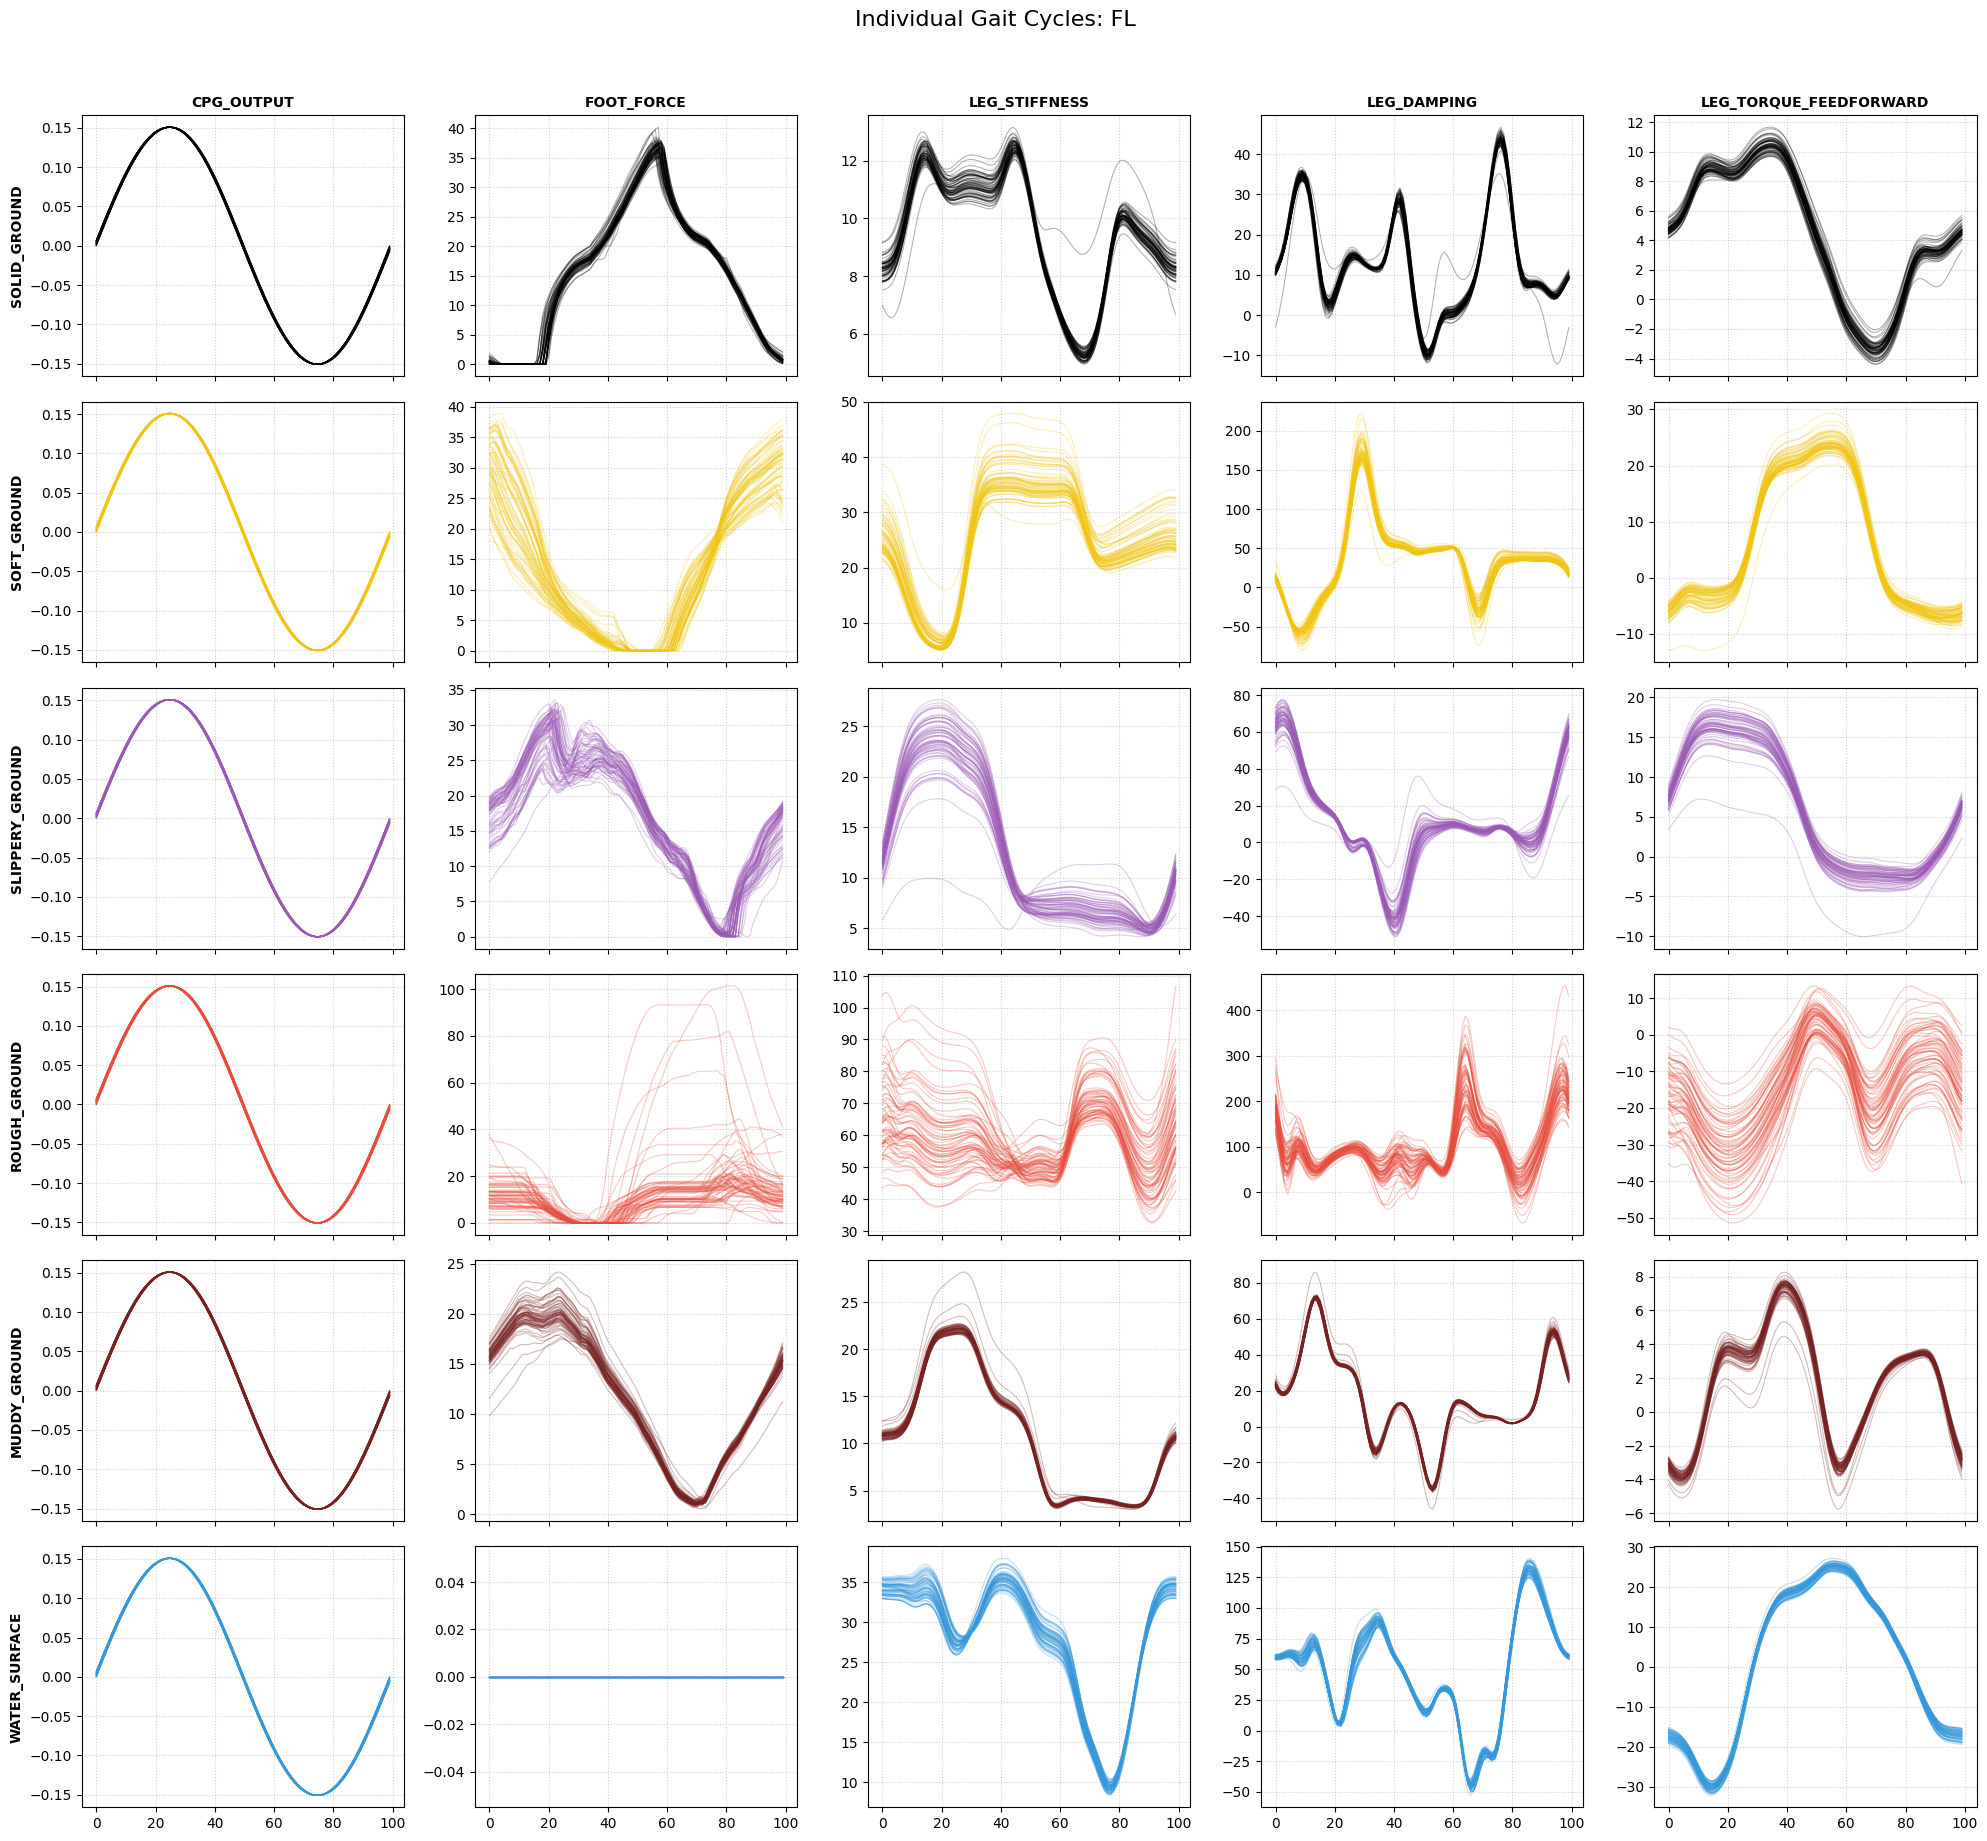

In [46]:
sensors_to_plot = ['cpg_output', 'foot_force', 'leg_stiffness', 'leg_damping', 'leg_torque_feedforward']
plot_all_individual_cycles(test_data, sensors_to_plot, leg_idx=2)

In [47]:
def flatten_datasets(dataset_dict, terrain_to_id_map, sensor_order):
	"""
	Converts the nested dictionary into flat X and y lists for the ESN.
	
	dataset_dict: The output from your split_dataset function.
	terrain_to_id_map: Dictionary mapping string terrain names to integers (e.g., {'concrete': 0, 'grass': 1}).
	sensor_order: A strict list of sensor dictionary keys to ensure columns are always in the same order.
	"""
	X_formatted = []
	y_formatted = []
	
	for terrain, sensors_data in dataset_dict.items():
		if terrain not in terrain_to_id_map:
			continue # Skip terrains we aren't training on
			
		label = terrain_to_id_map[terrain]
		
		# Get the number of cycles for this terrain (they are synchronized)
		n_cycles = len(sensors_data[sensor_order[0]])
		
		for i in range(n_cycles):
			# For cycle 'i', gather data from all 16 joints (K, D, tau)
			cycle_columns = []
			for sensor_name in sensor_order:
				# Ensure it's a numpy array
				sensor_array = np.array(sensors_data[sensor_name][i])
				
				# If the sensor data is 1D (e.g., shape (90,)), reshape to (90, 1) so it stacks horizontally
				if len(sensor_array.shape) == 1:
					sensor_array = sensor_array.reshape(-1, 1)
					
				cycle_columns.append(sensor_array)
			
			# Stack all sensors horizontally to create the (90 timesteps x 48 features) matrix
			full_gait_matrix = np.hstack(cycle_columns)
			
			X_formatted.append(full_gait_matrix)
			y_formatted.append(label)
			
	return X_formatted, np.array(y_formatted)

## Training

In [50]:
from models.model_1_esn.env_pred import ESN_RR_Classification
import itertools
import numpy as np


# ==========================================
# 1. DEFINITIONS & CONFIGURATIONS
# ==========================================
TERRAIN_LABELS = {
    'solid_ground'      : 0,
    'soft_ground'       : 1,
    'slippery_ground'   : 2,
    'rough_ground'      : 3,
    'muddy_ground'      : 4,
    'water_surface'     : 5
}

# Define a list of ALL the different sensor configurations you want to test
SENSOR_CONFIGURATIONS = [
    ['joint_stiffness_fb', 'joint_damping_fb', 'joint_torque_ff_fb'],
    ['leg_stiffness', 'leg_damping', 'leg_torque_feedforward'],
    ['joint_torque_fb'],
    ['joint_torque_fb', 'foot_force'],
    ['foot_force']
]

# Define the Hyperparameter Grid
param_grid = {
    'n_reservoir': [100], # , 150, 250, 500, 750 
    'leak_rate': [0.1, 0.3, 0.5, 0.8],
    'spectral_radius': [0.8, 0.9, 0.95],
    'lambda_reg': [0.001, 0.01, 0.1]
}

keys = param_grid.keys()
combinations = list(itertools.product(*param_grid.values()))

In [52]:
# ==========================================
# 2. MAIN SEARCH LOOP
# ==========================================
if SEARCH_BEST_ESN_MODEL:
    print(f"Total Hyperparameter combinations per config: {len(combinations)}\n")
    
    # Ensure the save directory exists
    os.makedirs("trained_models", exist_ok=True)

    # Loop through each sensor configuration
    for config_idx, current_sensor_keys in enumerate(SENSOR_CONFIGURATIONS):
        
        # --- THE NEW NAMING CONVENTION ---
        # config_idx starts at 0, so we add 1 to get "config_1", "config_2", etc.
        config_name = f"config_{config_idx + 1}"
        
        print("\n" + "#"*60)
        print(f"🚀 STARTING SEARCH [{config_name} / {len(SENSOR_CONFIGURATIONS)}]")
        print(f"📡 Sensors: {current_sensor_keys}")
        print("#"*60)

        # --- Format dataset for THIS specific configuration ---
        X_train, y_train = flatten_datasets(train_data, TERRAIN_LABELS, current_sensor_keys)
        X_test, y_test = flatten_datasets(test_data, TERRAIN_LABELS, current_sensor_keys)
        test_sample = X_test[0] 
        leak_found = any(np.array_equal(test_sample, train_sample) for train_sample in X_train)
        if leak_found:
            print("🚨 WARNING: DATA LEAKAGE DETECTED! Test data is inside training data!")
        else:
            print("✅ Data split is clean! No exact duplicates found.")
             
        print(f"Total Training Cycles: {len(X_train)}")
        print(f"Total Testing Cycles: {len(X_test)}")
        if len(X_train) > 0:
            print(f"Input Matrix Shape: {X_train[0].shape}\n") 

        # --- Run the Search for this Configuration ---
        best_accuracy = 0.0
        best_params = None
        best_model = None

        for i, values in enumerate(combinations):
            params = dict(zip(keys, values))
            
            print(f"  [{i+1}/{len(combinations)}] Testing: res={params['n_reservoir']}, leak={params['leak_rate']}, "
                  f"sr={params['spectral_radius']}, lam={params['lambda_reg']}...", end="")
            
            # Initialize and train
            model = ESN_RR_Classification(
                n_reservoir=params['n_reservoir'], 
                leak_rate=params['leak_rate'], 
                spectral_radius=params['spectral_radius'], 
                lambda_reg=params['lambda_reg']
            )
            
            model.fit(X_train, y_train)
            
            # Evaluate
            correct = 0
            for j in range(len(X_test)):
                predicted_class, _ = model.predict(X_test[j])
                if predicted_class == y_test[j]:
                    correct += 1
                    
            accuracy = (correct / len(X_test)) * 100
            print(f" -> Accuracy: {accuracy:.2f}%")
            
            # Track the best model for THIS configuration
            if accuracy > best_accuracy:
                best_accuracy = accuracy
                best_params = params
                best_model = model

        # --- Report and Save the Best Model for this Configuration ---
        print("\n" + "="*50)
        print(f"🏆 BEST MODEL FOUND FOR: {config_name.upper()}")
        print(f"Accuracy: {best_accuracy:.2f}%")
        print("Parameters:")
        for k, v in best_params.items():
            print(f" - {k}: {v}")
        print("="*50 + "\n")

        # Save using the new config_X naming convention
        filename = f"trained_models/model_1_esn_{config_name}.pt"
        if best_model is not None:
            best_model.save_model(filename)
            
print("\n✅ ALL CONFIGURATIONS TESTED AND SAVED!")

Total Hyperparameter combinations per config: 36


############################################################
🚀 STARTING SEARCH [config_1 / 5]
📡 Sensors: ['joint_stiffness_fb', 'joint_damping_fb', 'joint_torque_ff_fb']
############################################################
✅ Data split is clean! No exact duplicates found.
Total Training Cycles: 168
Total Testing Cycles: 396
Input Matrix Shape: (100, 51)

  [1/36] Testing: res=100, leak=0.1, sr=0.8, lam=0.001...Processing 168 gait cycles through the reservoir...
Solving for Readout Weights using Ridge Regression...
ESN Training complete. Readout weight shape: (6, 100)
 -> Accuracy: 100.00%
  [2/36] Testing: res=100, leak=0.1, sr=0.8, lam=0.01...Processing 168 gait cycles through the reservoir...
Solving for Readout Weights using Ridge Regression...
ESN Training complete. Readout weight shape: (6, 100)
 -> Accuracy: 100.00%
  [3/36] Testing: res=100, leak=0.1, sr=0.8, lam=0.1...Processing 168 gait cycles through the reservoir...


- It's not complete to collect dataset BROOO!! 
- We need to collect different gait pattern either!!